In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [39]:
# Load preprocessed parquet data
of_df = pd.read_parquet("/Users/betsyfrdmn/Lucas_Code_Local/of_df.parquet")

In [40]:
# Columns of the dataframe
of_df.columns

Index(['ActivityCode', 'UserID', 'WorkCode', 'AssignmentID', 'ProductID',
       'Quantity', 'Timestamp', 'LocationID', 'Aisle', 'Bay', 'Level', 'Slot',
       'ProductCode', 'UnitOfMeasure', 'Weight', 'Cube', 'Length', 'Width',
       'Height', 'Hour', 'Pick_Time_Hours', 'Pick_Time_Secs', 'Shift',
       'Location', 'Prior_Location', 'Distance'],
      dtype='object')

In [41]:
# Some rows of the dataset
of_df.head()

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Aisle,Bay,...,Length,Width,Height,Hour,Pick_Time_Hours,Pick_Time_Secs,Shift,Location,Prior_Location,Distance
0,PickPut,80,30,7801774,244.0,1.0,2025-09-08 21:11:23.960,4715097.0,70,36,...,NaN,NaN,NaN,21,NaN,NaN,1,70|36|||,None,NaN
1,PickPut,80,30,7799033,49196.0,8.0,2025-09-08 21:18:26.900,920815.0,71,01,...,NaN,NaN,NaN,21,0.117483,7.049000,1,71|01|||,70|36|||,157.0
2,PickPut,80,30,7799056,49196.0,6.0,2025-09-08 21:18:43.053,920815.0,71,01,...,NaN,NaN,NaN,21,0.004487,0.269217,1,71|01|||,71|01|||,0.0
3,PickPut,80,30,7800307,14786.0,1.0,2025-09-08 21:19:09.267,940141.0,71,01,...,NaN,NaN,NaN,21,0.007282,0.436900,1,71|01|||,71|01|||,0.0
4,PickPut,80,30,7799135,114.0,4.0,2025-09-08 21:19:27.833,1089974.0,71,03,...,NaN,NaN,NaN,21,0.005157,0.309433,1,71|03|||,71|01|||,8.0


# Activity Frequency

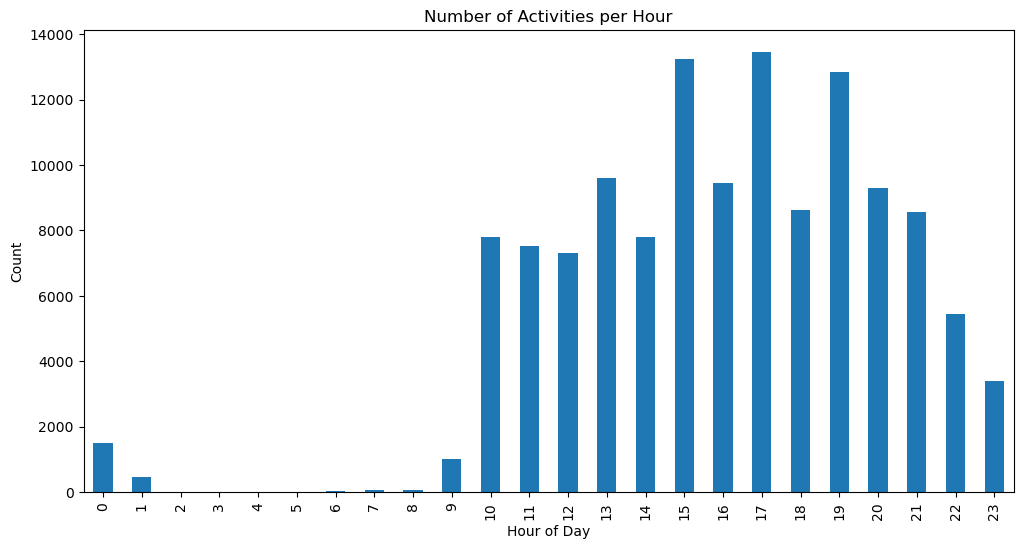

In [42]:
# Aggregate and visualize activities by hour of day
hour_counts = of_df["Hour"].value_counts().sort_index().reindex(range(24), fill_value=0)
hour_counts.plot(kind="bar", figsize=(12,6))
plt.xlabel("Hour of Day"); plt.ylabel("Count"); plt.title("Number of Activities per Hour")
plt.show()

# Data Exploration

In [43]:
# Review stats and distributions for categorical variables
of_df[["Quantity", "Weight", "Cube"]].describe()

,Quantity,Weight,Cube
count,126808.000000,126582.000000,126582.000000
mean,8.888177,5.442953,0.527723
std,32.432011,9.239953,0.930133
min,1.000000,0.000000,0.000000
25%,1.000000,0.159000,0.018000
50%,2.000000,1.200000,0.128000
75%,8.000000,7.000000,0.756000
max,2400.000000,539.000000,23.518000


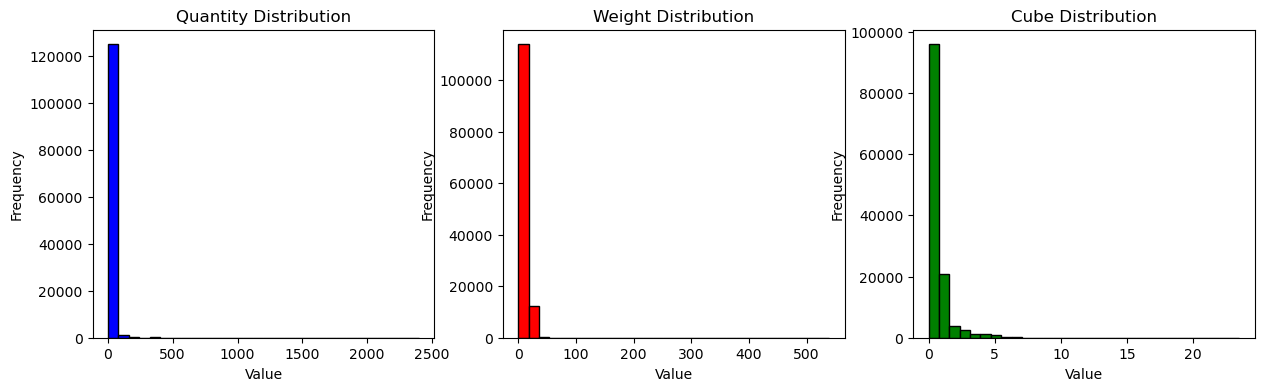

In [44]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
axes[0].hist(of_df["Quantity"], bins=30, color='blue', edgecolor='black')
axes[0].set_title('Quantity Distribution')

axes[1].hist(of_df["Weight"], bins=30, color='red', edgecolor='black')
axes[1].set_title('Weight Distribution')

axes[2].hist(of_df["Cube"], bins=30, color='green', edgecolor='black')
axes[2].set_title('Cube Distribution')

for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.show()

In [45]:
# Check unique levels, aisles, and bays to understand spatial distribution
of_df["Level"].value_counts().sort_index()

Level
1.0     53896
2.0     28616
3.0     21787
4.0     11885
5.0      5123
6.0      1487
7.0      1111
8.0       966
9.0       818
10.0      522
11.0      597
Name: count, dtype: int64

In [46]:
of_df["Bay"].unique()

array(['36', '01', '03', '05', '11', '13', '15', '12', '06', '04', '07',
       '02', '10', '19', '21', '25', '27', '20', '18', '17', '22', '28',
       '23', '26', '30', '32', '24', '14', '16', '42', '44', '37', '47',
       '08', '09', '48', '55', '39', '53', '33', '50', '40', '35', '54',
       '51', '38', '31', '29', '41', '43', '34', '56', None, '45', '52',
       '46', '49'], dtype=object)

In [47]:
of_df["Aisle"].unique()

array(['70', '71', '72', '74', '73', '75', '20', '30', '32', '37', '39',
       '40', '43', '44', '84', '87', '23', '25', '27', '28', '42', '24',
       '31', '41', '26', '29', '21', '22', '36', None, '65', '19', '38',
       '66', '85', '52', '53', '56', '64', '86', '83', '88', '54', '55',
       '82', '50', '57', '51', '59', '58'], dtype=object)

# Shift & Task Time Analysis

In [48]:
# Convert timestamps and group by user to identify discrete shifts (3-hour inactivity threshold)
of_df["Timestamp"] = pd.to_datetime(of_df["Timestamp"])
of_df = of_df.sort_values(["UserID", "Timestamp"])
of_df["Hour"] = of_df["Timestamp"].dt.floor("H")
of_df["Time_Diff"] = of_df.groupby("UserID")["Timestamp"].diff().dt.total_seconds() / 3600
of_df["Shift"] = (of_df["Time_Diff"] >= 3).groupby(of_df["UserID"]).cumsum() + 1
# Clear the first row of each shift as it has no valid preceding interval
of_df.loc[of_df.groupby(["UserID", "Shift"]).cumcount() == 0, "Time_Diff"] = np.nan

/var/folders/r9/zx84vhy57q9_n8tk5dnw8g980000gn/T/ipykernel_88926/1452550632.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  of_df["Hour"] = of_df["Timestamp"].dt.floor("H")


# Pick Time Distributions

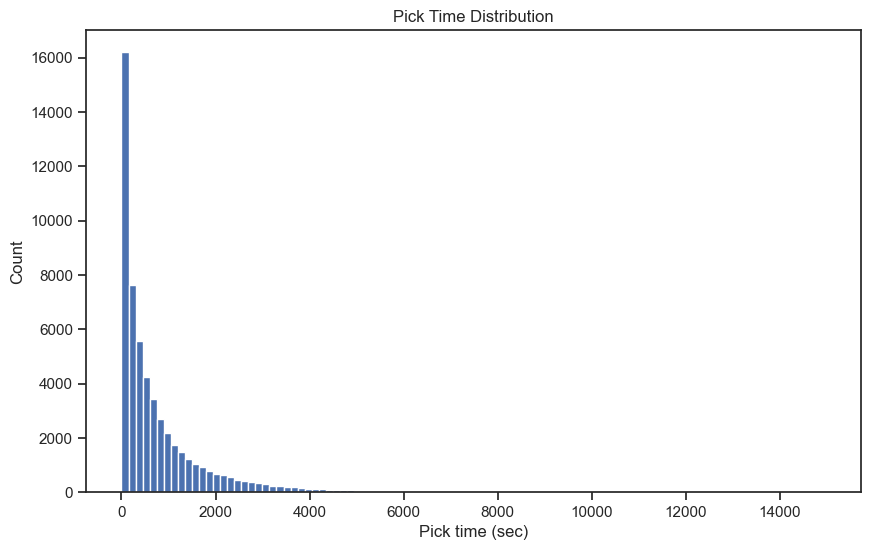

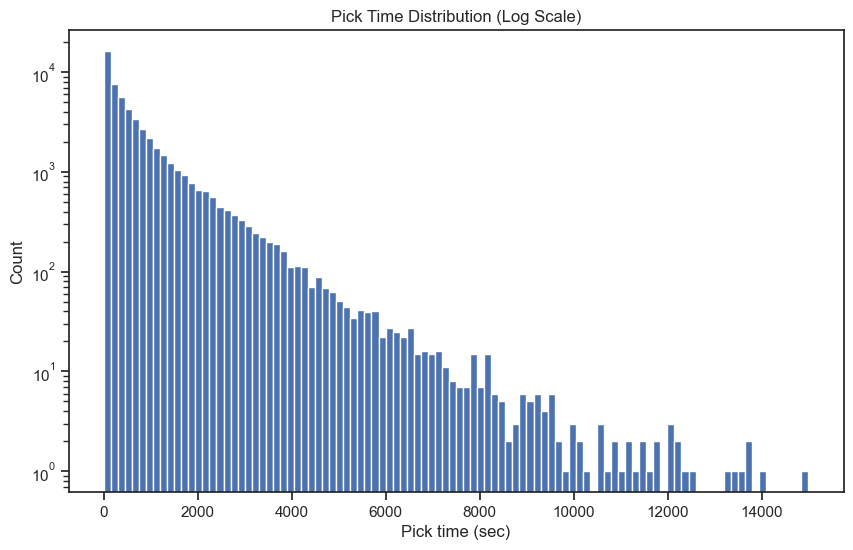

In [85]:
# Standard Histogram
plt.figure(figsize=(10,6))
plt.hist(of_df["Pick_Time_Secs"], bins=100)
plt.xlabel("Pick time (sec)"); plt.ylabel("Count")
plt.title("Pick Time Distribution"); plt.show()

# Log Scale Histogram
plt.figure(figsize=(10,6))
plt.hist(of_df["Pick_Time_Secs"], bins=100)
plt.xlabel("Pick time (sec)"); plt.ylabel("Count")
plt.yscale("log")
plt.title("Pick Time Distribution (Log Scale)"); plt.show()

# Time Distribution Visualizations

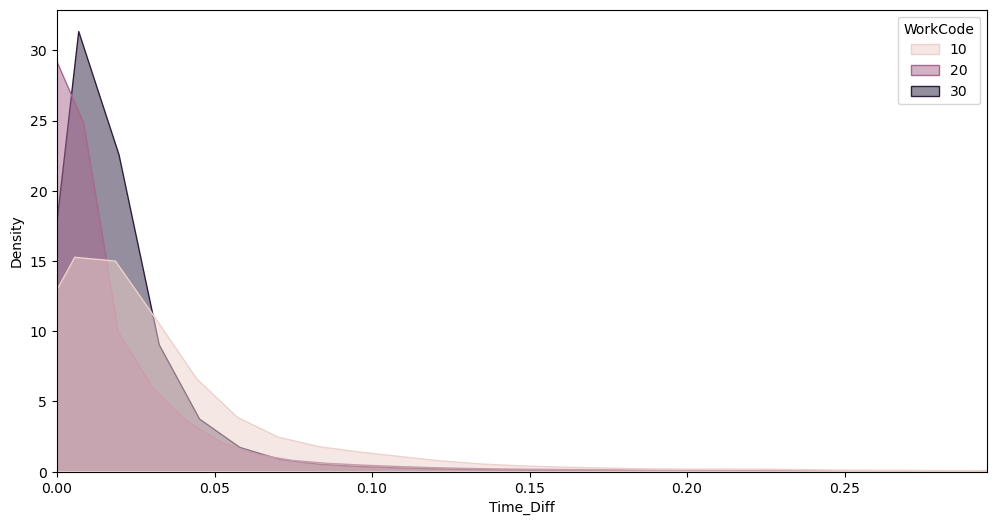

In [49]:
# Plot pick/put duration density by WorkCode
plt.figure(figsize=(12, 6))
plot_df = of_df.dropna(subset=["Time_Diff"])
sns.kdeplot(data=plot_df, x="Time_Diff", hue="WorkCode", fill=True, common_norm=False, alpha=0.5)
plt.xlim(0, plot_df["Time_Diff"].quantile(0.99))
plt.show()

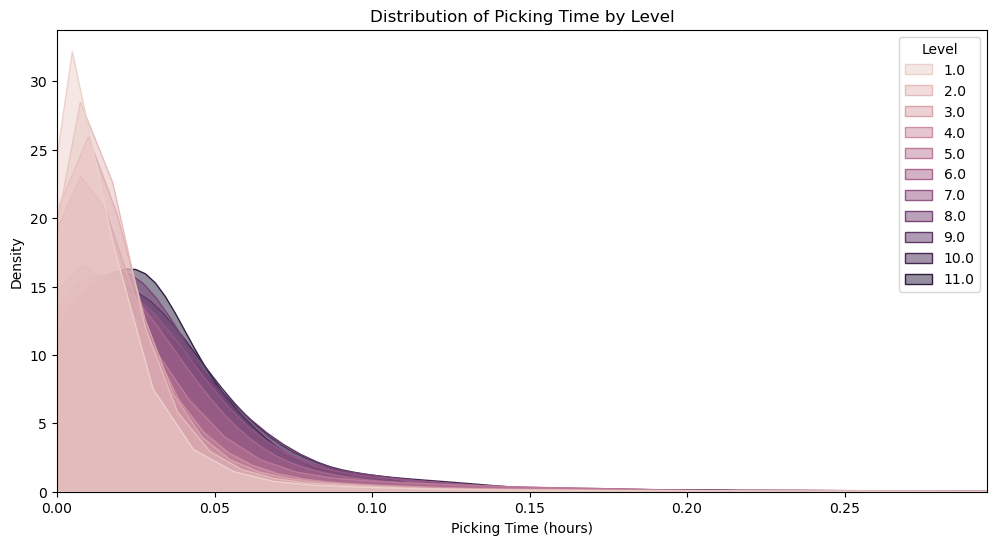

In [50]:
plot_df = of_df.dropna(subset=["Time_Diff"])

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=plot_df,
    x="Time_Diff",
    hue="Level",
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.xlabel("Picking Time (hours)")
plt.ylabel("Density")
plt.title("Distribution of Picking Time by Level")
plt.xlim(0, plot_df["Time_Diff"].quantile(0.99))
plt.show()


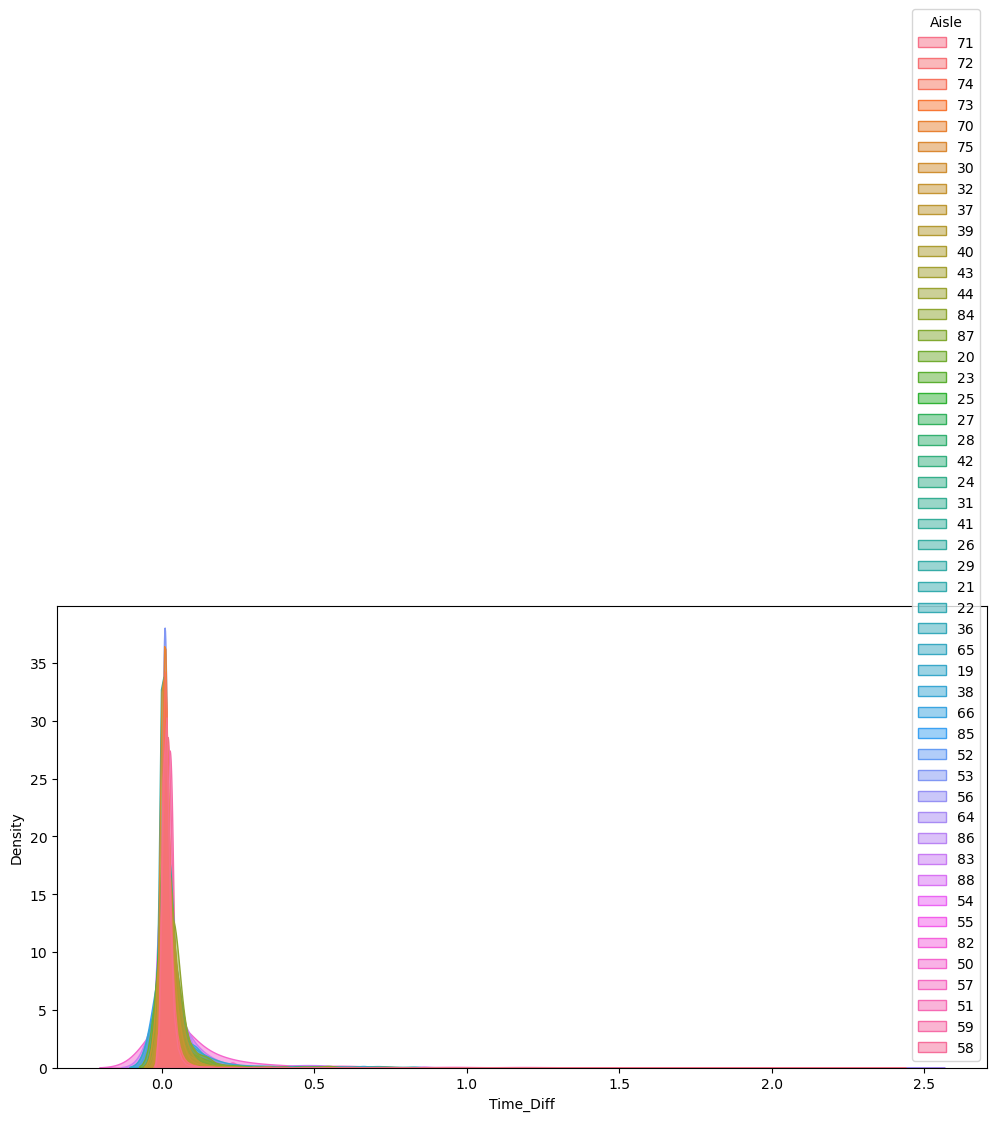

In [51]:
# Plot pick duration density by Aisle to spot geographic performance variance
plt.figure(figsize=(12,6))
sns.kdeplot(data=plot_df, x="Time_Diff", hue="Aisle", fill=True, common_norm=False, alpha=0.5)
plt.show()

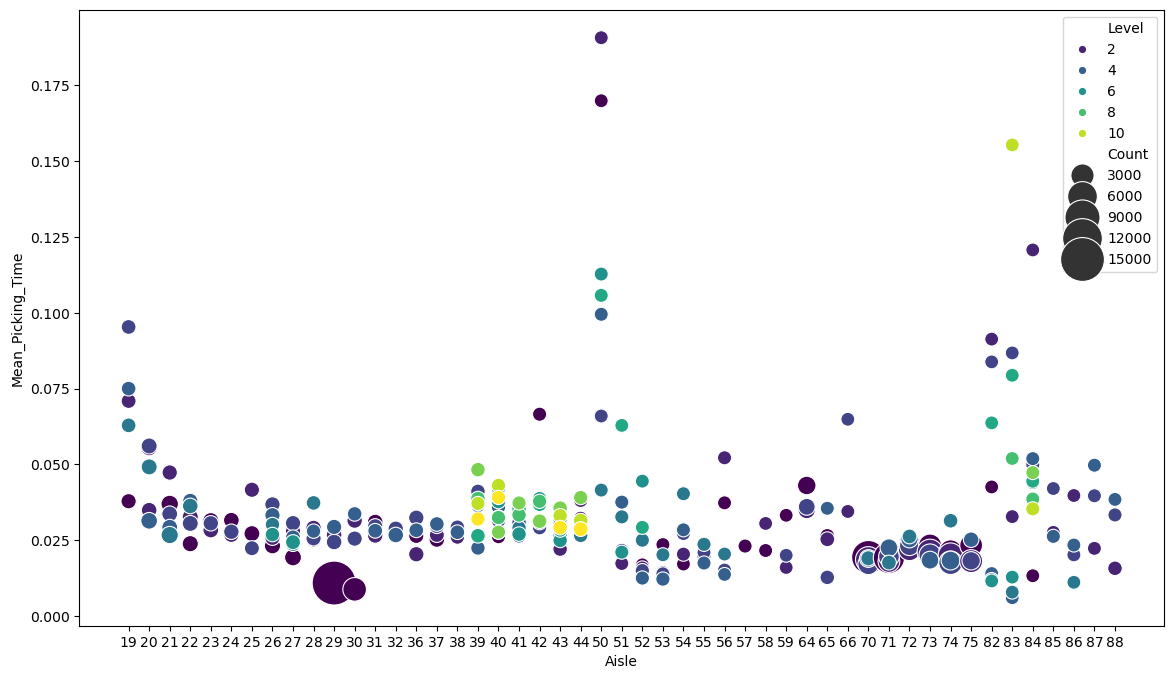

In [52]:
# Scatterplot showing mean picking time by Aisle and Level (size indicates sample count)
plt.figure(figsize=(14, 8))
plot_df = of_df.dropna(subset=["Time_Diff"]).groupby(["Aisle", "Level"]).agg(Mean_Picking_Time=("Time_Diff", "mean"), Count=("Time_Diff", "count")).reset_index()
sns.scatterplot(data=plot_df, x="Aisle", y="Mean_Picking_Time", size="Count", hue="Level", sizes=(100, 1000), palette="viridis")
plt.show()

# Travel Distance Distribution

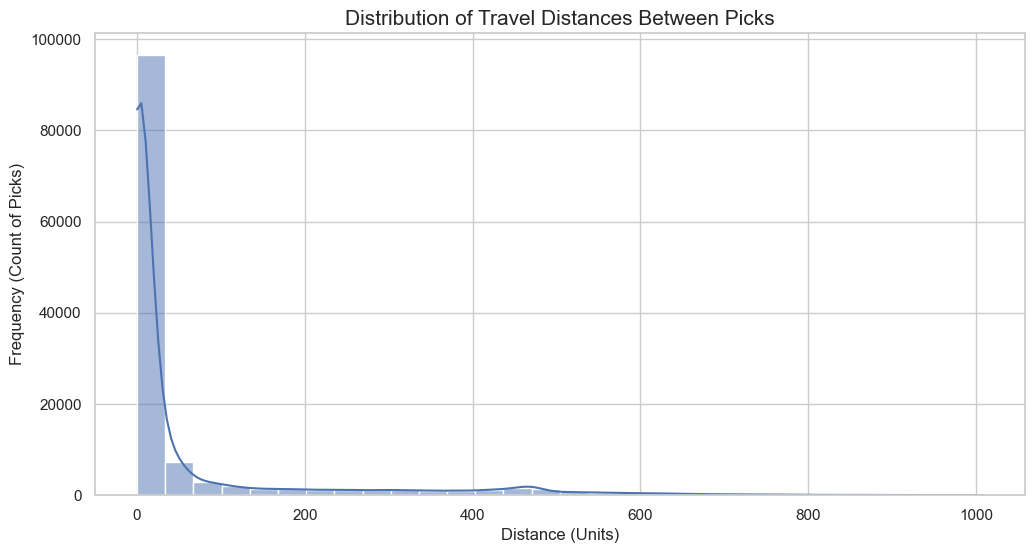

In [86]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(of_df['Distance'].dropna(), bins=30, kde=True)
plt.title('Distribution of Travel Distances Between Picks', fontsize=15)
plt.xlabel('Distance (Units)', fontsize=12)
plt.ylabel('Frequency (Count of Picks)', fontsize=12); plt.show()

# Daily Productivity Metrics

In [53]:
# Group by day to track daily throughput (tasks, assignments, volume)
of_df['Day'] = pd.to_datetime(of_df['Timestamp']).dt.date
daily_stats = of_df.groupby('Day').agg(picktasks=('ActivityCode', 'count'), assignments=('AssignmentID', 'nunique'), total_quantity=('Quantity', 'sum'), workers=('UserID', 'nunique')).reset_index()

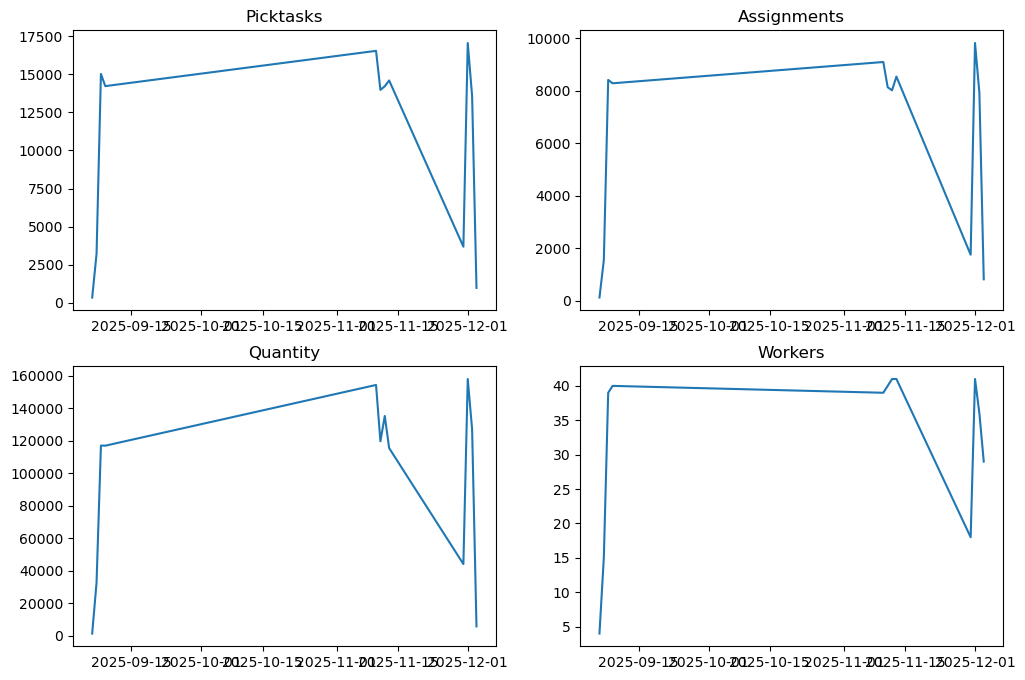

In [54]:
# Visualize trends in daily productivity
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, title, ax in [('picktasks', 'Picktasks', axes[0,0]), ('assignments', 'Assignments', axes[0,1]), ('total_quantity', 'Quantity', axes[1,0]), ('workers', 'Workers', axes[1,1])]:
    ax.plot(daily_stats['Day'], daily_stats[col]); ax.set_title(title)
plt.show()

In [55]:
of_df.groupby(["UserID", "Shift"]).agg({"Time_Diff": "sum"}).rename(columns={"Time_Diff": "Length_of_Shift"}).head(25)


Length_of_Shift
UserID Shift                 
80     1             4.567694
       2             1.498610
       3             4.304769
       4             0.564494
       5             3.644825
307    1             6.265409
       2             5.932933
       3             5.994751
       4             5.536219
       5             6.012359
       6             5.839042
       7             5.710996
       8             5.658510
326    1            11.332534
       2             9.197115
       3            10.157718
       4            10.123506
       5            11.082049
350    1             3.017492
       2             0.358449
443    1             4.997292
       2            10.192081
       3             9.740868
       4            12.038042
       5             6.223272

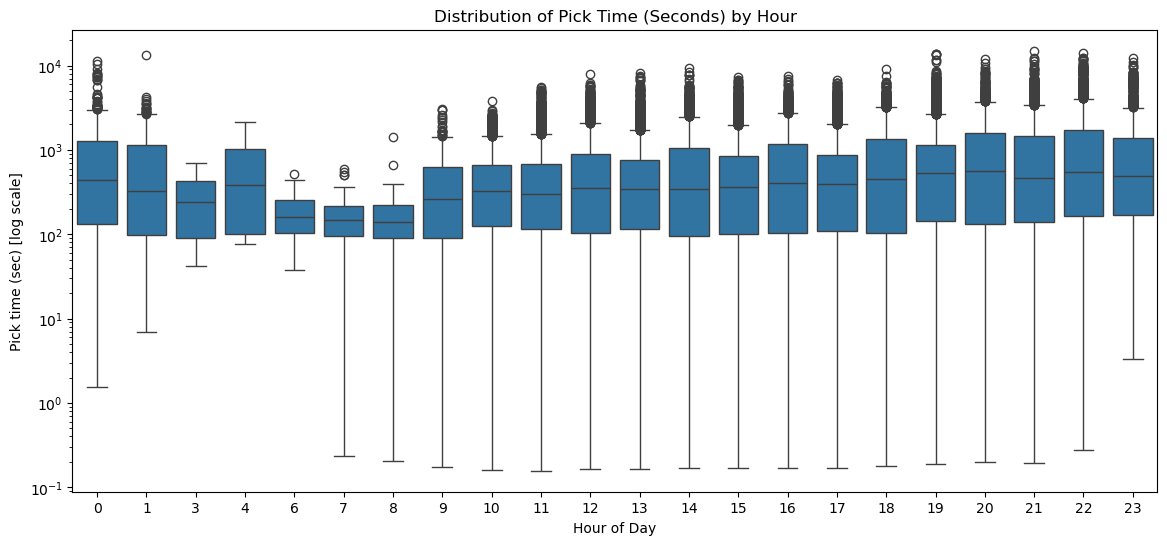

In [69]:
# Use .dt.hour to get the integer (0-23)
of_df["Hour"] = of_df["Timestamp"].dt.hour
# Aggregate pick times by location and assignment (if you still need this for other steps)
agg = of_df.dropna(subset=["time_diff_sec"]).groupby(["AssignmentID", "LocationID", "WorkCode"], as_index=False).agg(
    mean_time=("time_diff_sec", "mean"), 
    n=("time_diff_sec", "count")
)

# Final Boxplot of pick times per hour (Log Scale)
plt.figure(figsize=(14,6))

# Use 'of_df' as the data source, as it contains 'Pick_Time_Secs' and 'Hour'
data = of_df.dropna(subset=['Pick_Time_Secs', 'Hour'])

sns.boxplot(
    x='Hour', 
    y='Pick_Time_Secs', 
    data=data, 
    showfliers=True
)

plt.yscale('log')
plt.title('Distribution of Pick Time (Seconds) by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Pick time (sec) [log scale]')
plt.show()

# Average Pick Time for each Aisle and Level

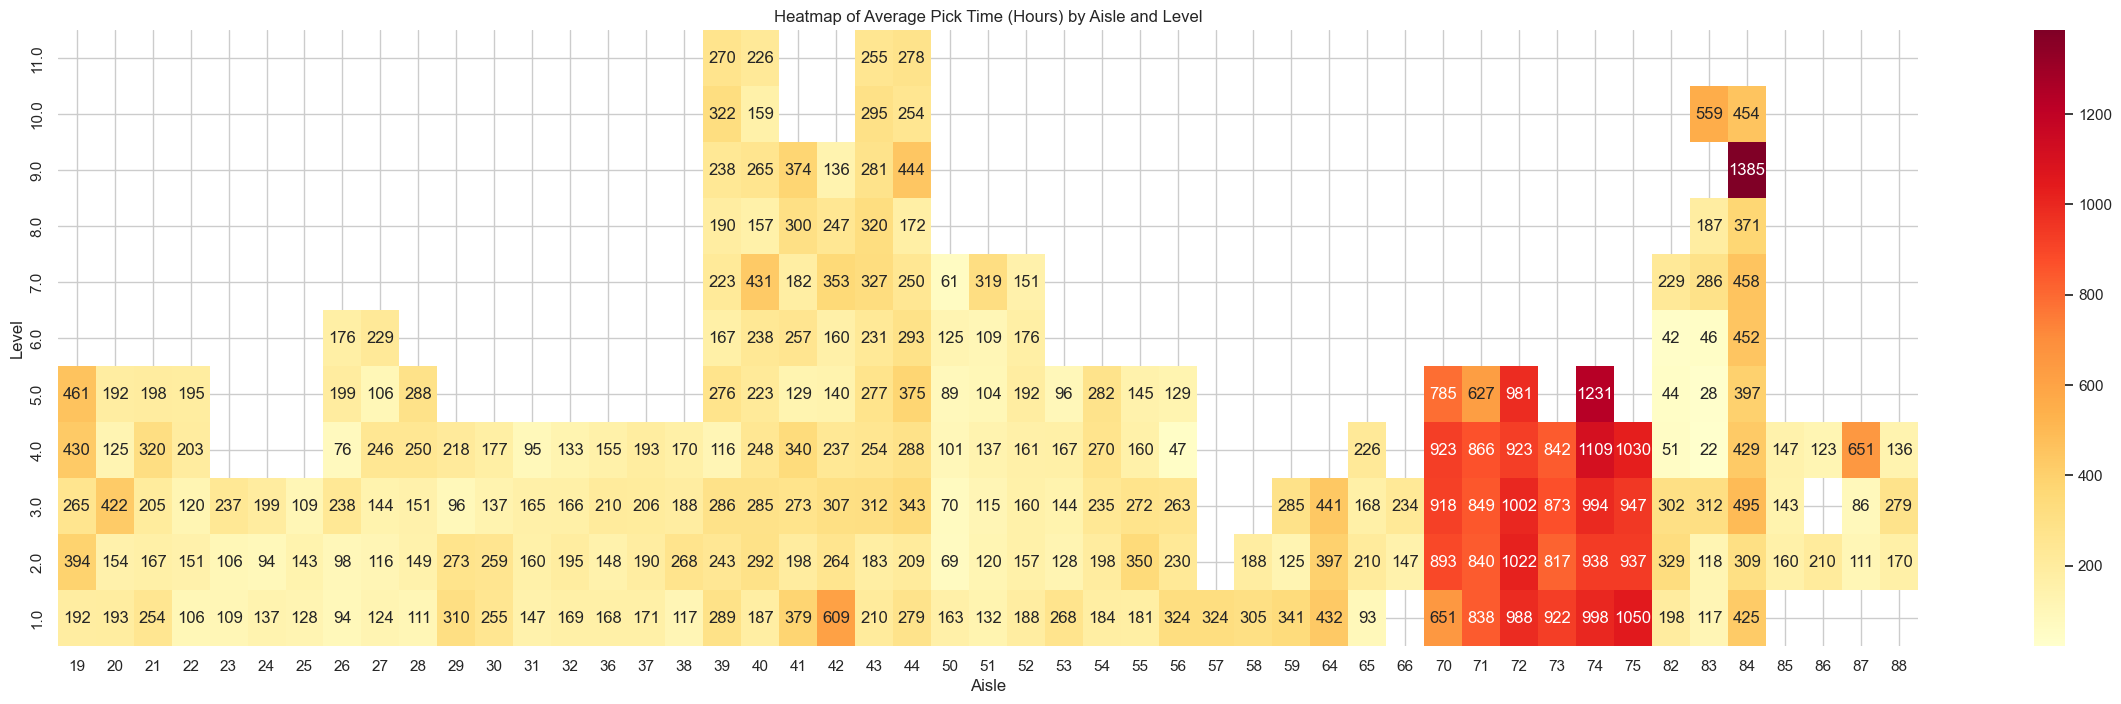

In [87]:
pivot_df = of_df.pivot_table(
    index='Level', 
    columns='Aisle', 
    values='Pick_Time_Secs', 
    aggfunc='mean'
).sort_index(ascending=False)
  
plt.figure(figsize=(30, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt='.0f')
plt.title('Heatmap of Average Pick Time (Hours) by Aisle and Level')
plt.show()